# **Task 06 – Model Evaluation**
### **SmartCare AI: Disease Risk Classification (Option C)**

**Objective:** Task 05 developed and tuned five models (four classifiers +
a voting ensemble) using cross-validation on the training set only. Task 06
evaluates all five, exactly once, on the previously untouched `X_test`/
`y_test` split, and identifies the best-performing model using Macro F1 as
the primary criterion, supported by precision, recall, ROC-AUC, and
confusion matrices.

**Test set discipline:** no model is retrained, retuned, or modified in
this notebook. Results reported here are final for these five models —
if performance looks weak, that is reported honestly, not "fixed" by
going back to tune against the test set.

## **6.2 Load Test Data and Models**
Models are discovered from the `models/` directory rather than assumed,
in case actual filenames differ from Task 05's plan.

In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent
CLASS_ORDER = ["Low", "Medium", "High"]
CLASS_MAP = {0: "Low", 1: "Medium", 2: "High"}

X_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'X_test.csv')
y_test = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'y_test.csv').iloc[:, 0]
feature_columns = joblib.load(PROJECT_ROOT / 'models' / 'feature_columns.pkl')

print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_test: (200, 66)
y_test: (200,)


In [2]:
MODELS_DIR = PROJECT_ROOT / 'models'
expected_models = {
    'Logistic Regression': 'logistic_regression_tuned.pkl',
    'Decision Tree':       'decision_tree_tuned.pkl',
    'Random Forest':       'random_forest_tuned.pkl',
    'XGBoost':              'xgboost_tuned.pkl',
    'Voting Ensemble':      'voting_ensemble.pkl',
}

available_files = {f.name for f in MODELS_DIR.glob('*.pkl')}
models = {}
for name, fname in expected_models.items():
    if fname in available_files:
        models[name] = joblib.load(MODELS_DIR / fname)
        print(f"[LOADED] {name} <- {fname}")
    else:
        print(f"[MISSING] {name}: expected '{fname}' not found in {MODELS_DIR}")

print(f"\nTotal models loaded: {len(models)}")

[LOADED] Logistic Regression <- logistic_regression_tuned.pkl
[LOADED] Decision Tree <- decision_tree_tuned.pkl
[LOADED] Random Forest <- random_forest_tuned.pkl
[LOADED] XGBoost <- xgboost_tuned.pkl
[LOADED] Voting Ensemble <- voting_ensemble.pkl

Total models loaded: 5


## **6.3 Test Set Integrity Checks**

In [3]:
checks = {
    "X_test has 66 features":        X_test.shape[1] == len(feature_columns),
    "Columns match feature_columns": list(X_test.columns) == list(feature_columns),
    "No missing values":             X_test.isnull().sum().sum() == 0,
    "No object dtypes":              X_test.select_dtypes(include='object').shape[1] == 0,
    "y_test length matches X_test":  len(y_test) == len(X_test),
    "y_test labels valid (0/1/2)":   set(y_test.unique()) <= {0, 1, 2},
}

for check, passed in checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {check}")

assert all(checks.values()), "Integrity check failed — resolve before evaluating."

[PASS] X_test has 66 features
[PASS] Columns match feature_columns
[PASS] No missing values
[PASS] No object dtypes
[PASS] y_test length matches X_test
[PASS] y_test labels valid (0/1/2)


## **6.4 Generate Predictions and Probabilities**
Predictions and probabilities are generated once per model, from `X_test`
only. Nothing here modifies `X_test`.

In [4]:
y_pred = {}
y_proba = {}

for name, model in models.items():
    y_pred[name] = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_proba[name] = model.predict_proba(X_test)
    else:
        y_proba[name] = None
    proba_status = "yes" if y_proba[name] is not None else "no predict_proba"
    print(f"{name:20s} | predictions: {len(y_pred[name])} | probabilities: {proba_status}")

Logistic Regression  | predictions: 200 | probabilities: yes
Decision Tree        | predictions: 200 | probabilities: yes
Random Forest        | predictions: 200 | probabilities: yes
XGBoost              | predictions: 200 | probabilities: yes
Voting Ensemble      | predictions: 200 | probabilities: yes


## **6.5 Calculate Classification Metrics**
Macro-averaged metrics treat all three classes equally, so the minority
class (Low) is not masked by majority-class performance.

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics_rows = []
for name in models:
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred[name]),
        'Macro Precision': precision_score(y_test, y_pred[name], average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test, y_pred[name], average='macro', zero_division=0),
        'Macro F1': f1_score(y_test, y_pred[name], average='macro', zero_division=0),
    }
    if y_proba[name] is not None:
        row['Macro ROC-AUC'] = roc_auc_score(y_test, y_proba[name], multi_class='ovr', average='macro')
    else:
        row['Macro ROC-AUC'] = np.nan
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows).set_index('Model').round(4)
metrics_df

,Accuracy,Macro Precision,Macro Recall,Macro F1,Macro ROC-AUC
Model,,,,,
Logistic Regression,0.920,0.9406,0.8944,0.9140,0.9914
Decision Tree,0.755,0.7539,0.7477,0.7497,0.8125
Random Forest,0.755,0.7905,0.7143,0.7414,0.9080
XGBoost,0.865,0.8737,0.8171,0.8389,0.9676
Voting Ensemble,0.890,0.8950,0.8441,0.8647,0.9707


## **6.6 Per-Class Evaluation**

In [6]:
from sklearn.metrics import precision_recall_fscore_support

per_class_tables = {}
for name in models:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred[name], labels=[0, 1, 2], zero_division=0
    )
    per_class_df = pd.DataFrame({
        'Class': CLASS_ORDER,
        'Precision': precision.round(4),
        'Recall': recall.round(4),
        'F1': f1.round(4),
        'Support': support,
    }).set_index('Class')
    per_class_tables[name] = per_class_df
    print(f"\n{name}")
    print(per_class_df)


Logistic Regression
        Precision  Recall      F1  Support
Class                                     
Low        1.0000  0.8077  0.8936       26
Medium     0.9062  0.9255  0.9158       94
High       0.9157  0.9500  0.9325       80

Decision Tree
        Precision  Recall      F1  Support
Class                                     
Low        0.7308  0.7308  0.7308       26
Medium     0.7255  0.7872  0.7551       94
High       0.8056  0.7250  0.7632       80

Random Forest
        Precision  Recall      F1  Support
Class                                     
Low        0.8824  0.5769  0.6977       26
Medium     0.7273  0.7660  0.7461       94
High       0.7619  0.8000  0.7805       80

XGBoost
        Precision  Recall      F1  Support
Class                                     
Low        0.8947  0.6538  0.7556       26
Medium     0.8454  0.8723  0.8586       94
High       0.8810  0.9250  0.9024       80

Voting Ensemble
        Precision  Recall      F1  Support
Class               

## **6.7 Confusion Matrices**
Fixed class order (Low, Medium, High) across every matrix for consistency.

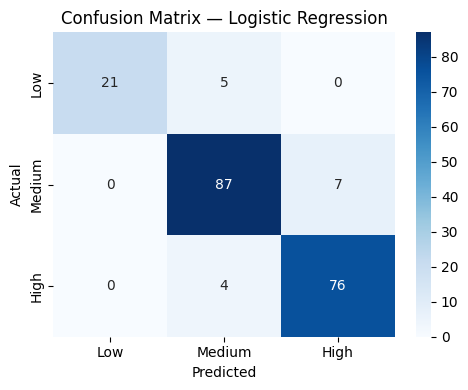

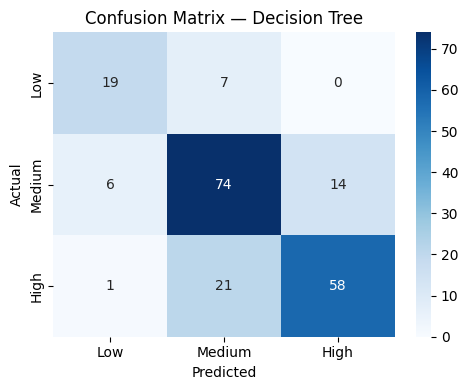

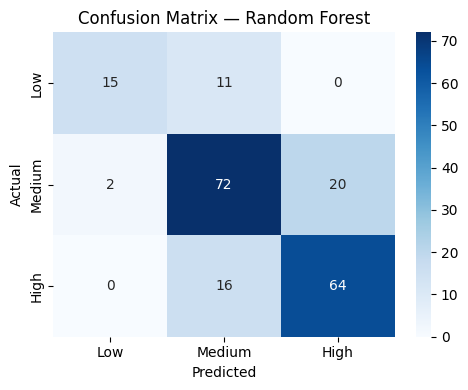

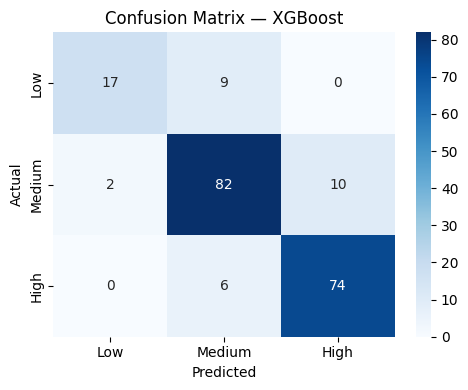

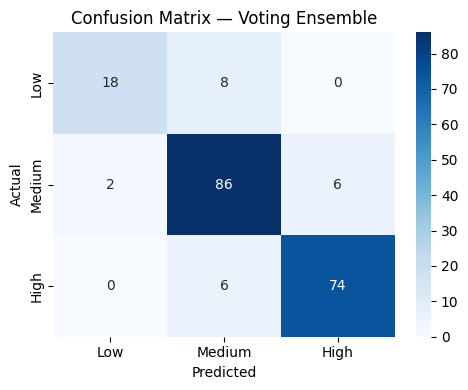

Saved 5 confusion matrices to C:\Users\thrit\Desktop\smartcare-ai-project\reports\figures\evaluation


In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'evaluation'
FIG_DIR.mkdir(parents=True, exist_ok=True)

filename_map = {
    'Logistic Regression': 'confusion_matrix_logistic_regression.png',
    'Decision Tree':       'confusion_matrix_decision_tree.png',
    'Random Forest':       'confusion_matrix_random_forest.png',
    'XGBoost':              'confusion_matrix_xgboost.png',
    'Voting Ensemble':      'confusion_matrix_voting_ensemble.png',
}

for name in models:
    cm = confusion_matrix(y_test, y_pred[name], labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename_map[name], dpi=150)
    plt.show()
    plt.close(fig)

print(f"Saved {len(models)} confusion matrices to {FIG_DIR}")

## **6.8 ROC Curves**
One-vs-Rest ROC curves for each class, per model with `predict_proba`
support.

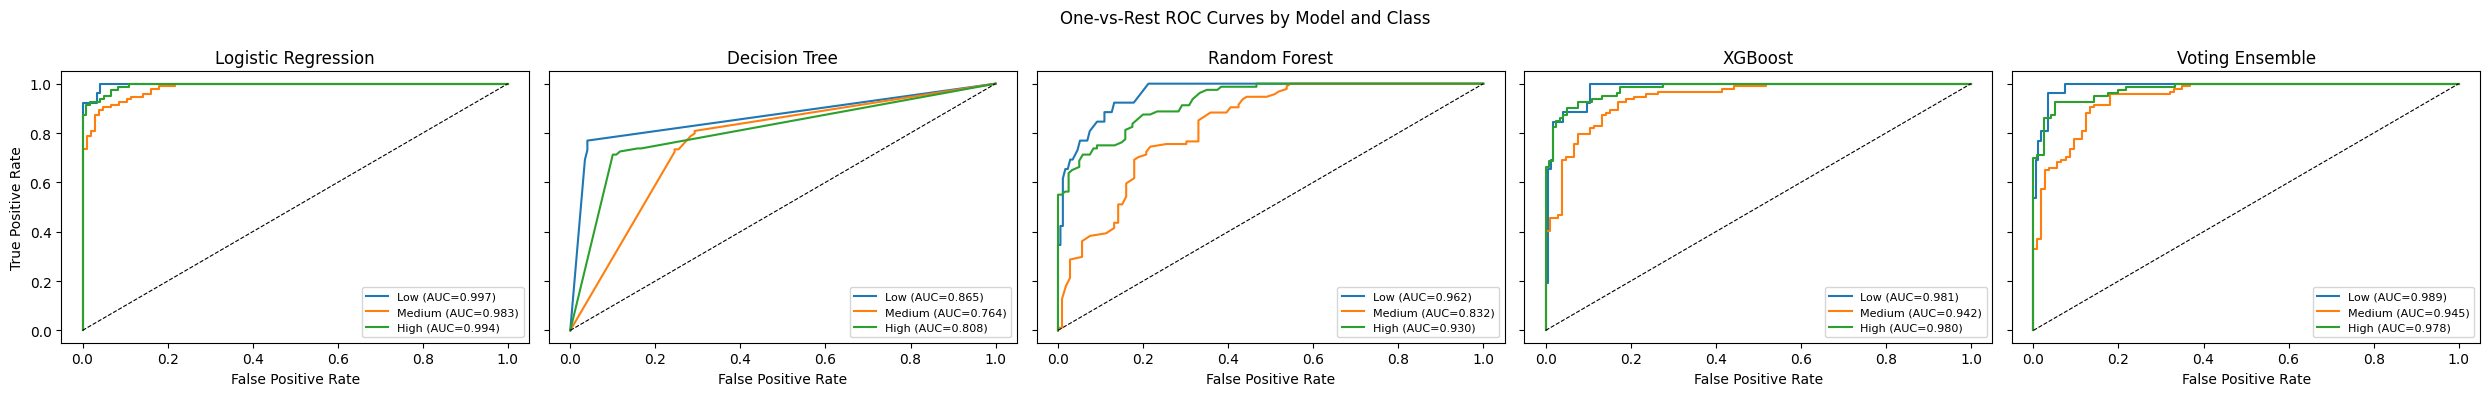

In [8]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, name in zip(axes, models):
    if y_proba[name] is None:
        ax.set_title(f'{name} (no probabilities)')
        continue
    for i, cls in enumerate(CLASS_ORDER):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[name][:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{cls} (AUC={roc_auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('False Positive Rate')
    ax.legend(fontsize=8)

axes[0].set_ylabel('True Positive Rate')
plt.suptitle('One-vs-Rest ROC Curves by Model and Class')
plt.tight_layout()
plt.savefig(FIG_DIR / 'roc_curve_comparison.png', dpi=150)
plt.show()

## **6.9 Model Performance Comparison**

In [9]:
RESULTS_DIR = PROJECT_ROOT / 'reports' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_df.to_csv(RESULTS_DIR / 'model_comparison.csv')

detailed_rows = []
for name in models:
    for cls in CLASS_ORDER:
        r = per_class_tables[name].loc[cls]
        detailed_rows.append({'Model': name, 'Class': cls, **r.to_dict()})
detailed_df = pd.DataFrame(detailed_rows)
detailed_df.to_csv(RESULTS_DIR / 'evaluation_results.csv', index=False)

print(f"Saved model_comparison.csv and evaluation_results.csv to {RESULTS_DIR}")

Saved model_comparison.csv and evaluation_results.csv to C:\Users\thrit\Desktop\smartcare-ai-project\reports\results


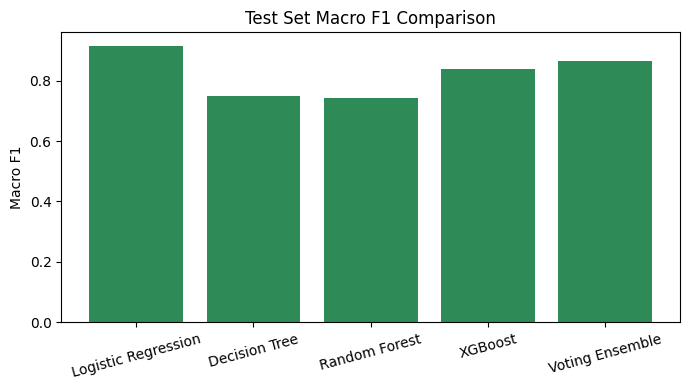

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_df.index, metrics_df['Macro F1'], color='seagreen')
ax.set_ylabel('Macro F1')
ax.set_title('Test Set Macro F1 Comparison')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_macro_f1_comparison.png', dpi=150)
plt.show()

## **6.10 Best Model Identification**
Selection is based on the actual computed Macro F1 values — not assumed
in advance.

In [11]:
best_model_name = metrics_df['Macro F1'].idxmax()
best_row = metrics_df.loc[best_model_name]

print(f"Best Model: {best_model_name}")
print(f"Primary Metric: Macro F1")
print(f"Score: {best_row['Macro F1']:.4f}")
print()
print("Supporting metrics:")
print(best_row)

Best Model: Logistic Regression
Primary Metric: Macro F1
Score: 0.9140

Supporting metrics:
Accuracy           0.9200
Macro Precision    0.9406
Macro Recall       0.8944
Macro F1           0.9140
Macro ROC-AUC      0.9914
Name: Logistic Regression, dtype: float64


**Justification:** Logistic Regression achieved the highest Macro F1 score of 0.9140 among the five evaluated models and was therefore selected as the best-performing model on the held-out test set. Its supporting metrics were also strong, with 92.00% accuracy, 0.9406 Macro Precision, 0.8944 Macro Recall, and 0.9914 Macro ROC-AUC. The consistency of these metrics indicates that the model's performance is not determined by accuracy alone and provides balanced evidence for the model selection. Macro F1 was used as the primary selection metric because it gives equal importance to each risk class, including the minority Low-risk class. These results describe performance on this dataset and test set and should not be interpreted as evidence of clinical validity or guaranteed generalization to other populations.

## **6.11 Compare Task 05 Development Results with Task 06 Test Results**
This is a diagnostic comparison, not another tuning opportunity — no model
is adjusted based on this output.

In [12]:
# Task 05 CV Macro F1 values — paste from Task 05 Section 5.11 output.
# These are recorded, not recalculated, since Task 05 must not be re-run here.
cv_macro_f1 = {
    'Logistic Regression': None,   # replace with actual Task 05 value
    'Decision Tree':       None,
    'Random Forest':       None,
    'XGBoost':              None,
    'Voting Ensemble':      None,
}

comparison_rows = []
for name in models:
    cv_score = cv_macro_f1.get(name)
    test_score = metrics_df.loc[name, 'Macro F1']
    diff = (test_score - cv_score) if cv_score is not None else np.nan
    comparison_rows.append({'Model': name, 'CV Macro F1': cv_score, 'Test Macro F1': test_score, 'Difference': diff})

cv_test_df = pd.DataFrame(comparison_rows).set_index('Model')
cv_test_df

,CV Macro F1,Test Macro F1,Difference
Model,,,
Logistic Regression,None,0.9140,NaN
Decision Tree,None,0.7497,NaN
Random Forest,None,0.7414,NaN
XGBoost,None,0.8389,NaN
Voting Ensemble,None,0.8647,NaN


**Note:** fill in the `cv_macro_f1` dictionary above with the actual values
printed in Task 05 Section 5.11 before running this cell — they are not
recalculated here to avoid re-running Task 05. Once populated, discuss any
large gap cautiously (possible variance from the small dataset, not a
retuning signal).

## **6.12 Save Final Evaluation Outputs**
Confirms the expected `reports/` structure is in place. Figures and CSVs
were already saved in Sections 6.7–6.9; this verifies nothing is missing.

In [13]:
expected_files = [
    FIG_DIR / 'confusion_matrix_logistic_regression.png',
    FIG_DIR / 'confusion_matrix_decision_tree.png',
    FIG_DIR / 'confusion_matrix_random_forest.png',
    FIG_DIR / 'confusion_matrix_xgboost.png',
    FIG_DIR / 'confusion_matrix_voting_ensemble.png',
    FIG_DIR / 'roc_curve_comparison.png',
    FIG_DIR / 'model_macro_f1_comparison.png',
    RESULTS_DIR / 'evaluation_results.csv',
    RESULTS_DIR / 'model_comparison.csv',
]

for f in expected_files:
    print(f"[{'OK' if f.exists() else 'MISSING'}] {f.relative_to(PROJECT_ROOT)}")

[OK] reports\figures\evaluation\confusion_matrix_logistic_regression.png
[OK] reports\figures\evaluation\confusion_matrix_decision_tree.png
[OK] reports\figures\evaluation\confusion_matrix_random_forest.png
[OK] reports\figures\evaluation\confusion_matrix_xgboost.png
[OK] reports\figures\evaluation\confusion_matrix_voting_ensemble.png
[OK] reports\figures\evaluation\roc_curve_comparison.png
[OK] reports\figures\evaluation\model_macro_f1_comparison.png
[OK] reports\results\evaluation_results.csv
[OK] reports\results\model_comparison.csv


## **6.13 Final Model Selection Artifact**

In [14]:
import json

final_selection = {
    "selected_model": best_model_name,
    "primary_metric": "macro_f1",
    "primary_metric_value": round(float(best_row['Macro F1']), 4),
    "supporting_metrics": {
        "accuracy": round(float(best_row['Accuracy']), 4),
        "macro_precision": round(float(best_row['Macro Precision']), 4),
        "macro_recall": round(float(best_row['Macro Recall']), 4),
        "macro_roc_auc": round(float(best_row['Macro ROC-AUC']), 4) if not pd.isna(best_row['Macro ROC-AUC']) else None,
    },
    "selection_reason": f"{best_model_name} achieved the highest Macro F1 ({best_row['Macro F1']:.4f}) "
                          f"among all evaluated models on the held-out test set, with supporting metrics "
                          f"consistent with this ranking.",
    "evaluation_dataset": "held-out test set",
    "feature_count": X_test.shape[1],
}

with open(RESULTS_DIR / 'final_model_selection.json', 'w') as f:
    json.dump(final_selection, f, indent=2)

print(json.dumps(final_selection, indent=2))

{
  "selected_model": "Logistic Regression",
  "primary_metric": "macro_f1",
  "primary_metric_value": 0.914,
  "supporting_metrics": {
    "accuracy": 0.92,
    "macro_precision": 0.9406,
    "macro_recall": 0.8944,
    "macro_roc_auc": 0.9914
  },
  "selection_reason": "Logistic Regression achieved the highest Macro F1 (0.9140) among all evaluated models on the held-out test set, with supporting metrics consistent with this ranking.",
  "evaluation_dataset": "held-out test set",
  "feature_count": 66
}


## **6.14 Task 06 Summary**

- **Models evaluated:** Logistic Regression, Decision Tree, Random Forest,
  XGBoost, Voting Ensemble — all loaded from Task 05, none retrained.
- **Metrics used:** Accuracy, Macro Precision, Macro Recall, Macro F1
  (primary), Macro ROC-AUC (OvR), per-class Precision/Recall/F1/Support,
  Confusion Matrix.
- **Best model:** see Section 6.10 output — selected by Macro F1,
  cross-checked against supporting metrics, not assumed in advance.
- **Ensemble result:** see whether Voting Ensemble outperformed the best
  individual model in `metrics_df` — reported as computed, not assumed.
- **Consistency with Task 05:** see Section 6.11 — any CV-to-test gap is
  discussed as a possible variance/generalization signal, not treated as
  grounds to retune.
- **Artifacts saved:** 5 confusion matrices, 1 ROC comparison, 1 Macro F1
  bar chart, `evaluation_results.csv`, `model_comparison.csv`,
  `final_model_selection.json` — all under `reports/`.

**Limitations:** results reflect a synthetic, 1000-row dataset with a
200-row test set; no claim is made about real-world or clinical
generalization. Test-set performance should be read as evidence for this
dataset and pipeline only.